In [10]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

We want OpenCV to automatically determine:

"There is a straight line here."

The problem is that an image doesn't directly contain a mathematical y = mx + c line. It contains pixels.

The Hough Transform converts the problem from:

"Which pixels form a line?" into: "Which mathematical line is supported by the largest number of pixels?"

This is called voting. The same idea can be extended to circles.

In Hough Line threshould is important. Canny edges is important In Probabilistic minLineLength, maxLineGap

minLineLength → minimum length of a line segment to detect.

Increase → ignores short lines.

Decrease → detects shorter lines.

maxLineGap → maximum gap allowed between two segments to consider them as one line.

Increase → connects lines with larger gaps.

Decrease → only connects segments with small gaps.

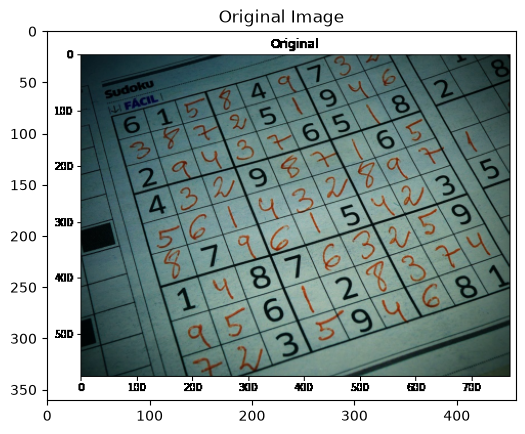

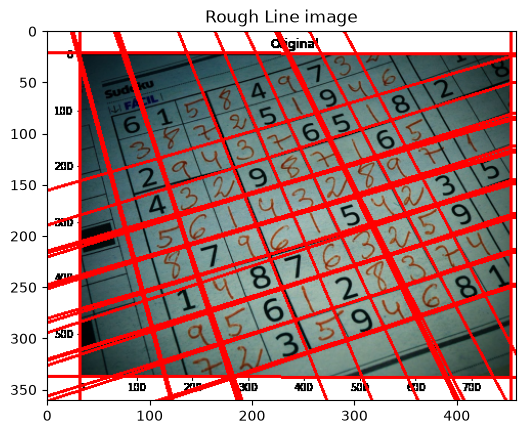

In [ ]:
image = cv2.imread('download.png')
plt.imshow(image)
plt.title("Original Image")
plt.show()

# Grayscale and Canny Edges extracted
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 60, 150)

# Run HoughLines using a rho accuracy of 1 pixel
# theta accuracy of np.pi / 180 which is 1 degree
# Our line threshold is set to 240 (number of points on line)
lines = cv2.HoughLines(edges, 1, np.pi / 180,165)

# We iterate through each line and convert it to the format
# required by cv2.lines (i.e. requiring end points)
if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(image, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.imshow(image)
plt.title("Hough Line image")
plt.show()

## Including ROI for better result

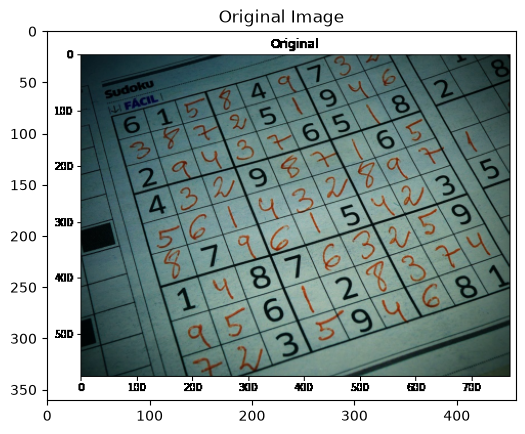

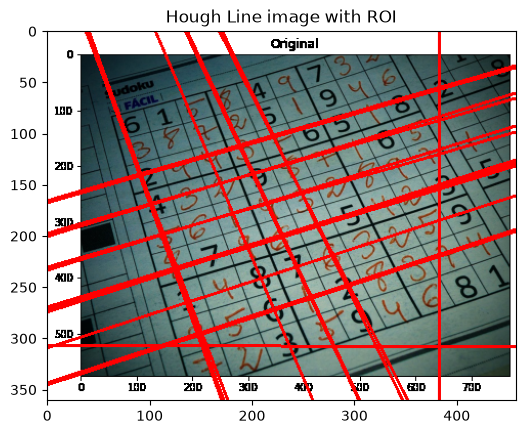

In [42]:
image = cv2.imread('download.png')
plt.imshow(image)
plt.title("Original Image")
plt.show()

# Grayscale and Canny Edges extracted
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
roi = gray[
    30:450,
    70:650
]
edges = cv2.Canny(roi, 50, 120)

# Run HoughLines using a rho accuracy of 1 pixel
# theta accuracy of np.pi / 180 which is 1 degree
# Our line threshold is set to 240 (number of points on line)
lines = cv2.HoughLines(edges, 1, np.pi / 180,170)

# We iterate through each line and convert it to the format
# required by cv2.lines (i.e. requiring end points)
if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(image, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.imshow(image)
plt.title("Hough Line image with ROI")
plt.show()

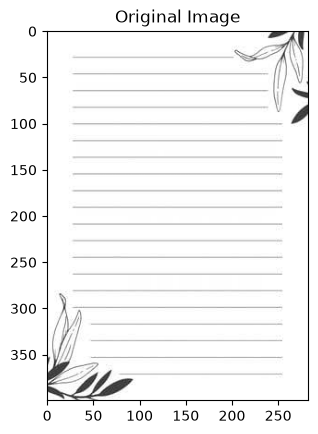

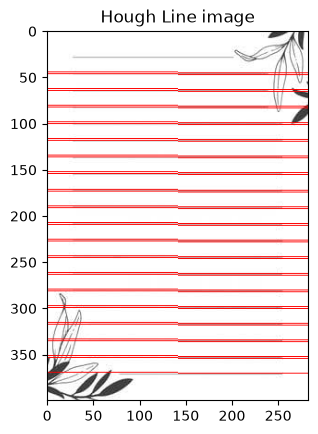

In [41]:
image = cv2.imread("lines.jpg")
plt.imshow(image)
plt.title("Original Image")
plt.show()

# Grayscale and Canny Edges extracted
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 60, 200)

# Run HoughLines using a rho accuracy of 1 pixel
# theta accuracy of np.pi / 180 which is 1 degree
# Our line threshold is set to 240 (number of points on line)
lines = cv2.HoughLines(edges, 1, np.pi / 180,200)

# We iterate through each line and convert it to the format
# required by cv2.lines (i.e. requiring end points)
if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(image, (x1, y1), (x2, y2), (255, 0, 0), 1)

plt.imshow(image)
plt.title("Hough Line image")
plt.show()

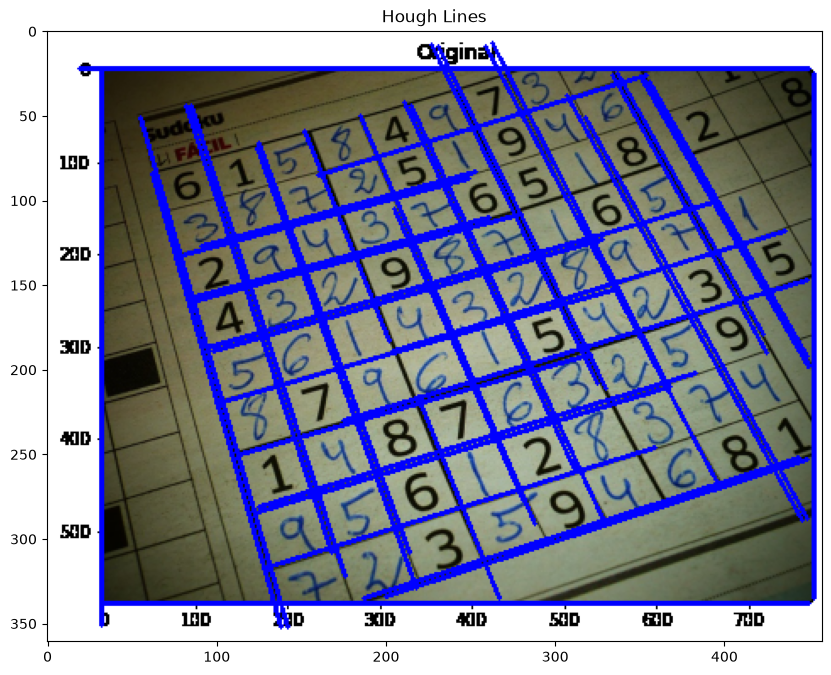

In [63]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("download.png")

# -----------------------------
# 1. Grayscale
# -----------------------------

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

# -----------------------------
# 2. Blur
# -----------------------------

blur = cv2.GaussianBlur(
    gray,
    (5, 5),
    0
)

# -----------------------------
# 3. Canny
# -----------------------------

edges = cv2.Canny(
    blur,
    30,
    160

)

# -----------------------------
# 4. Hough Lines
# -----------------------------

lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=120,
    minLineLength=100,
    maxLineGap=20
)

# -----------------------------
# 5. Draw lines
# -----------------------------

if lines is not None:

    for line in lines:

        x1, y1, x2, y2 = line.reshape(4)

        cv2.line(
            image,
            (x1, y1),
            (x2, y2),
            (255, 0, 0),
            2
        )

# -----------------------------
# 6. Display
# -----------------------------

plt.figure(figsize=(10, 8))

plt.imshow(
    cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
)

plt.title("Hough Lines")

plt.show()

# Hough Circle

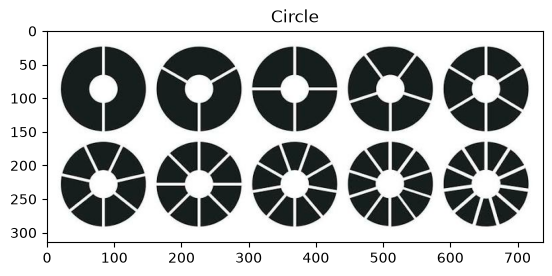

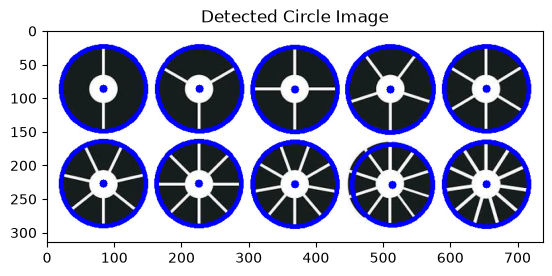

In [ ]:
image = cv2.imread('bw circle.jpg')
plt.imshow(image)
plt.title("Circle")
plt.show()


gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blur = cv2.medianBlur(gray, 5)

circles = cv2.HoughCircles(blur, cv2.HOUGH_GRADIENT, 1.25, 25)

# cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, 1.25, 100)

circles = np.uint16(np.around(circles))

for i in circles[0,:]:
    # draw the outer circle
    cv2.circle(image,(i[0], i[1]), i[2], (0, 0, 255), 5)
    
    # draw the center of the circle
    cv2.circle(image, (i[0], i[1]), 2, (0, 0, 255), 8)
''' i[0] → center X
    i[1] → center Y
    i[2] → radius
'''
plt.imshow(image)
plt.title("Detected Circle Image")
plt.show()

dp :- Controls the resolution of the accumulator.

minDist :- Minimum distance between detected circle centers.
too small → the same circle may be detected multiple times. --> too large → nearby real circles may be missed.

param1 :- Higher threshold used by the internal Canny edge detection.

param2 :- The circle detection threshold.

param2 ↓ → more circles detected → potentially more false positives
param2 ↑ → fewer circles detected → stricter detection

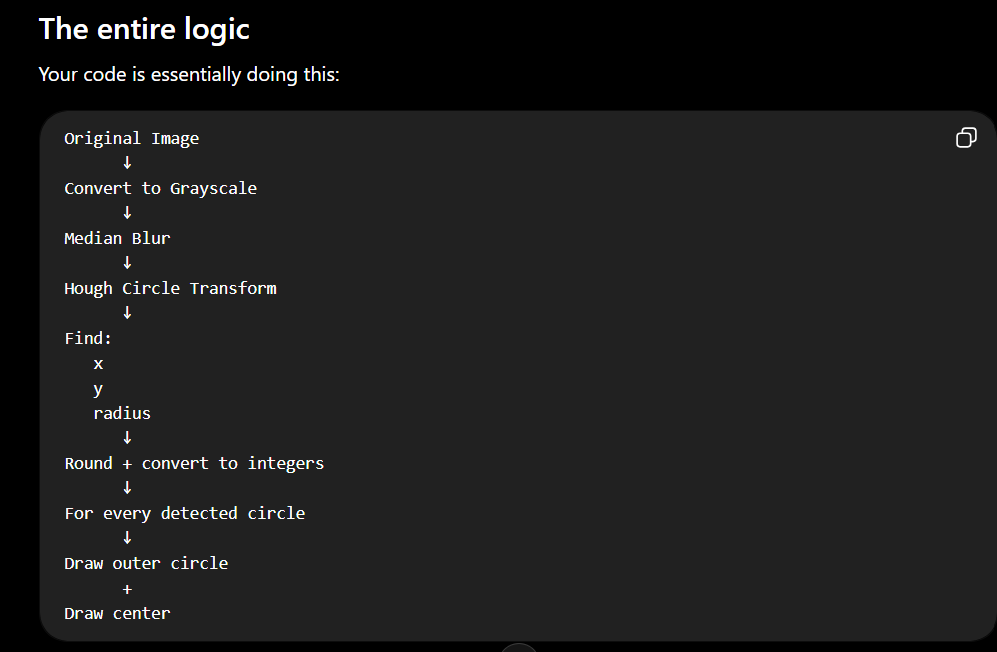

A blob is simply a region of an image where pixels have some common characteristic, such as:

Similar brightness;
Similar color;
Being connected;
Having a particular size or shape

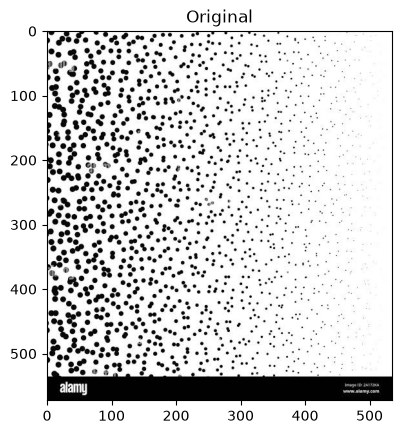

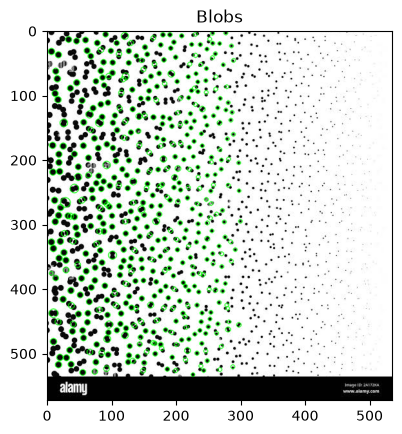

In [ ]:
image = cv2.imread("particles.jpg")
plt.imshow(image)
plt.title("Original")
plt.show()

# Set up the detector with default parameters.
detector = cv2.SimpleBlobDetector_create()
 
# Detect blobs.
keypoints = detector.detect(image)

# Draw detected blobs as red circles.
# cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS ensures the size of
# the circle corresponds to the size of blob
blank = np.zeros((1,1)) 
blobs = cv2.drawKeypoints(image, keypoints, blank, (0,255,0),
                                      cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
 
# Show keypoints
plt.imshow(blobs)
plt.title("Blobs")
plt.show()

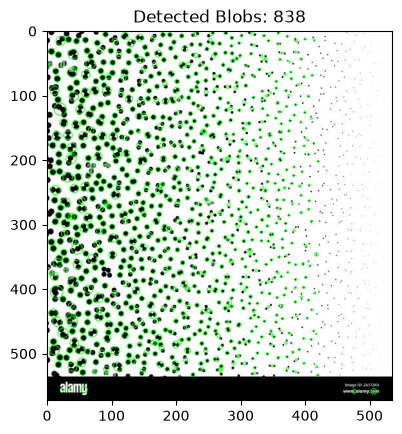

In [78]:
image = cv2.imread("particles.jpg")

params = cv2.SimpleBlobDetector_Params()

# Detect dark/black blobs
params.filterByColor = True
params.blobColor = 0

# Allow different dot sizes
params.filterByArea = True
params.minArea = 10
params.maxArea = 500

# Don't restrict the dots too much by shape
params.filterByCircularity = False
params.filterByConvexity = False
params.filterByInertia = False

# Create detector
detector = cv2.SimpleBlobDetector_create(params)

# Detect
keypoints = detector.detect(image)

# Draw
blobs = cv2.drawKeypoints(
    image,
    keypoints,
    None,
    (0, 255, 0),
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.imshow(cv2.cvtColor(blobs, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Blobs: {len(keypoints)}")
plt.show()